
# Water Pollution Data Analysis

| Name        | Student Number |
| ----------- | -------------- |
| Shangase LB | 22406973       |
| Xaba SN     | 22411202       |
| Ndlela A    | 22410926       |
| Ndlovu FS   | 22426265       |

## Project Title

**An Analysis of Water Pollution Using Data Science, Machine Learning and Dashboard**


## Dataset: Water Pollution Dataset

### What the dataset contains

The Water Pollution Dataset contains **3,000 records and 25 columns** related to water quality and pollution monitoring.

The dataset includes the following fields:

| Category | Columns |
|---|---|
| Location Information | Province, City, Monitoring_Station, Latitude, Longitude |
| Time Information | Date |
| Physical Water Measurements | Water_Temperature_C, pH, Dissolved_Oxygen_mg_L, Conductivity_uS_cm, Turbidity_NTU |
| Chemical Indicators | Nitrate_mg_L, Nitrite_mg_L, Ammonia_N_mg_L, Total_Phosphorus_mg_L, Total_Nitrogen_mg_L |
| Pollution Indicators | COD_mg_L, BOD_mg_L |
| Heavy Metals | Heavy_Metals_Pb_ug_L, Heavy_Metals_Cd_ug_L, Heavy_Metals_Hg_ug_L |
| Biological Indicator | Coliform_Count_CFU_100mL |
| Target/Quality Information | Water_Quality_Index, Pollution_Level, Remarks |

### Purpose of the Dataset

This dataset will be used to:

- Analyse water pollution patterns.
- Identify relationships between water quality variables.
- Classify pollution levels.
- Visualise environmental trends.
- Apply machine learning and time series forecasting techniques.

## Project Overview
This project uses data analysis and machine learning to investigate water pollution and build a model that can help predict water-quality outcomes. The project follows a complete machine-learning cycle, starting with collecting the data and ending with deploying the trained model.

## Machine Learning Project Cycle
**Collect Data → Prepare Data → Explore Data → Engineer Features → Train Model → Test Model → Evaluate Model → Deploy Model**

## What Each Step Does
1. **Collect Data** – Load the water pollution dataset that will be used for the project, inspect the data and import the libraries you are going to use.
2. **Prepare Data** – Clean the dataset, handle missing or incorrect values, and prepare the data for analysis.
3. **Explore Data** – Analyse the dataset using statistics and visualisations to understand patterns and relationships in the water-quality data.
4. **Engineer Features** – Select, transform, or create useful features that can improve the machine-learning model.
5. **Train Model** – Use the prepared training data to teach a machine-learning algorithm to identify patterns and make predictions.
6. **Test Model** – Use unseen test data to check how well the trained model performs on new data.
7. **Evaluate Model** – Measure the model's performance using appropriate evaluation methods and determine whether the predictions are reliable.
8. **Deploy Model** – Make the final trained model available so that it can be used to make predictions on new water-quality data.
   
 **Project goal:** To follow this complete cycle and develop a machine-learning solution that can use water-pollution data to support prediction and understanding of water-quality conditions.

## 1. Collect Data

Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Load the dataset

In [47]:
df = pd.read_csv("china_water_pollution_data.csv")
print("Dataset load sucessfully")

Dataset load sucessfully


## 2.Prepare data

In [48]:
print("Dataset shape:", df.shape,"\n")

Dataset shape: (3000, 25) 



In [49]:

print("View the first 5 records")

df.head()

View the first 5 records


,Province,City,Monitoring_Station,Latitude,Longitude,Date,Water_Temperature_C,pH,Dissolved_Oxygen_mg_L,Conductivity_uS_cm,...,Total_Nitrogen_mg_L,COD_mg_L,BOD_mg_L,Heavy_Metals_Pb_ug_L,Heavy_Metals_Cd_ug_L,Heavy_Metals_Hg_ug_L,Coliform_Count_CFU_100mL,Water_Quality_Index,Pollution_Level,Remarks
0,Zhejiang,Ningbo,Ningbo_Station_2,25.523836,122.622036,2023-06-01,22.48,6.93,9.30,652.30,...,2.71,15.38,1.39,6.90,0.66,0.02,87,36.64,Very Poor,High pollution spike detected
1,Sichuan,Mianyang,Mianyang_Station_1,32.243099,112.888760,2023-03-05,27.33,6.89,8.14,357.53,...,3.15,16.82,2.98,4.68,0.39,0.10,116,66.25,Excellent,High pollution spike detected
2,Zhejiang,Ningbo,Ningbo_Station_8,29.996179,124.744859,2023-07-13,21.04,6.02,5.34,519.69,...,3.39,17.31,2.65,3.24,0.27,0.11,110,98.69,Poor,High pollution spike detected
3,Beijing,Beijing,Beijing_Station_10,29.976437,118.274846,2023-02-17,16.62,7.31,10.06,593.13,...,2.91,17.95,5.18,3.20,0.67,0.11,99,71.32,Poor,Monitoring recommended
4,Sichuan,Chengdu,Chengdu_Station_1,43.524720,121.666111,2023-03-06,21.81,7.77,7.93,656.46,...,3.45,20.10,3.47,2.01,0.34,0.14,82,16.12,Excellent,NaN


In [19]:
print("View the 5 last records")

df.tail()

View the 5 last records


,Province,City,Monitoring_Station,Latitude,Longitude,Date,Water_Temperature_C,pH,Dissolved_Oxygen_mg_L,Conductivity_uS_cm,...,Total_Nitrogen_mg_L,COD_mg_L,BOD_mg_L,Heavy_Metals_Pb_ug_L,Heavy_Metals_Cd_ug_L,Heavy_Metals_Hg_ug_L,Coliform_Count_CFU_100mL,Water_Quality_Index,Pollution_Level,Remarks
2995,Shandong,Qingdao,Qingdao_Station_6,28.766067,100.662530,2023-11-03,14.26,6.68,8.83,465.49,...,3.34,13.18,2.32,5.61,0.49,0.11,115,9.18,Moderate,Monitoring recommended
2996,Guangdong,Shenzhen,Shenzhen_Station_3,34.608605,121.475802,2023-07-22,22.29,7.26,8.89,606.39,...,3.66,18.86,4.40,5.70,0.53,0.19,107,48.35,Excellent,NaN
2997,Shandong,Jinan,Jinan_Station_1,36.642090,102.593904,2023-06-29,26.02,6.08,6.91,378.42,...,2.35,20.42,4.58,5.55,0.62,0.05,102,61.78,Poor,Monitoring recommended
2998,Sichuan,Chengdu,Chengdu_Station_4,25.261258,119.203392,2023-01-10,22.64,6.77,8.11,462.59,...,2.73,21.58,3.50,-1.55,0.44,0.06,115,72.10,Good,Requires attention
2999,Yunnan,Kunming,Kunming_Station_5,24.071840,117.344491,2023-03-02,21.25,6.59,5.61,529.35,...,2.04,21.23,3.18,5.49,0.45,0.06,99,76.88,Poor,Requires attention


Inspect the data

In [42]:
print("Columns in the dataset:\n")

for column in df.columns:
    print(column)

Columns in the dataset:

Province
City
Monitoring_Station
Latitude
Longitude
Date
Water_Temperature_C
pH
Dissolved_Oxygen_mg_L
Conductivity_uS_cm
Turbidity_NTU
Nitrate_mg_L
Nitrite_mg_L
Ammonia_N_mg_L
Total_Phosphorus_mg_L
Total_Nitrogen_mg_L
COD_mg_L
BOD_mg_L
Heavy_Metals_Pb_ug_L
Heavy_Metals_Cd_ug_L
Heavy_Metals_Hg_ug_L
Coliform_Count_CFU_100mL
Water_Quality_Index
Pollution_Level
Remarks


Check data types

In [20]:
df.dtypes

Province                        str
City                            str
Monitoring_Station              str
Latitude                    float64
Longitude                   float64
Date                            str
Water_Temperature_C         float64
pH                          float64
Dissolved_Oxygen_mg_L       float64
Conductivity_uS_cm          float64
Turbidity_NTU               float64
Nitrate_mg_L                float64
Nitrite_mg_L                float64
Ammonia_N_mg_L              float64
Total_Phosphorus_mg_L       float64
Total_Nitrogen_mg_L         float64
COD_mg_L                    float64
BOD_mg_L                    float64
Heavy_Metals_Pb_ug_L        float64
Heavy_Metals_Cd_ug_L        float64
Heavy_Metals_Hg_ug_L        float64
Coliform_Count_CFU_100mL      int64
Water_Quality_Index         float64
Pollution_Level                 str
Remarks                         str
dtype: object

Convert columns to the correct data type

In [45]:

df = df.convert_dtypes()


Check the prepared dataset

In [41]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Province                  3000 non-null   string 
 1   City                      3000 non-null   string 
 2   Monitoring_Station        3000 non-null   string 
 3   Latitude                  3000 non-null   Float64
 4   Longitude                 3000 non-null   Float64
 5   Date                      3000 non-null   string 
 6   Water_Temperature_C       3000 non-null   Float64
 7   pH                        3000 non-null   Float64
 8   Dissolved_Oxygen_mg_L     3000 non-null   Float64
 9   Conductivity_uS_cm        3000 non-null   Float64
 10  Turbidity_NTU             3000 non-null   Float64
 11  Nitrate_mg_L              3000 non-null   Float64
 12  Nitrite_mg_L              3000 non-null   Float64
 13  Ammonia_N_mg_L            3000 non-null   Float64
 14  Total_Phosphorus_mg

Check for missing values again


In [38]:

df.isnull().sum()


Province                      0
City                          0
Monitoring_Station            0
Latitude                      0
Longitude                     0
Date                          0
Water_Temperature_C           0
pH                            0
Dissolved_Oxygen_mg_L         0
Conductivity_uS_cm            0
Turbidity_NTU                 0
Nitrate_mg_L                  0
Nitrite_mg_L                  0
Ammonia_N_mg_L                0
Total_Phosphorus_mg_L         0
Total_Nitrogen_mg_L           0
COD_mg_L                      0
BOD_mg_L                      0
Heavy_Metals_Pb_ug_L          0
Heavy_Metals_Cd_ug_L          0
Heavy_Metals_Hg_ug_L          0
Coliform_Count_CFU_100mL      0
Water_Quality_Index           0
Pollution_Level               0
Remarks                     752
dtype: int64

Remove duplicated

In [44]:

df = df.drop_duplicates()


Display summary statistics

In [40]:

df.describe()

,Latitude,Longitude,Water_Temperature_C,pH,Dissolved_Oxygen_mg_L,Conductivity_uS_cm,Turbidity_NTU,Nitrate_mg_L,Nitrite_mg_L,Ammonia_N_mg_L,Total_Phosphorus_mg_L,Total_Nitrogen_mg_L,COD_mg_L,BOD_mg_L,Heavy_Metals_Pb_ug_L,Heavy_Metals_Cd_ug_L,Heavy_Metals_Hg_ug_L,Coliform_Count_CFU_100mL,Water_Quality_Index
count,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
mean,32.297496,112.546009,20.051253,7.030207,8.0067,496.558537,4.94819,1.98291,0.019961,0.501583,0.100898,3.007363,19.98978,4.01456,4.978943,0.50073,0.09942,99.997333,50.262903
std,7.222235,7.24015,4.923307,0.496628,1.974517,98.874604,4.910484,0.507882,0.009926,0.200057,0.050109,0.498326,5.008402,1.005858,2.01743,0.197278,0.049419,9.992127,29.105637
min,20.014474,100.017169,3.39,5.34,1.47,136.85,0.0,0.23,-0.02,-0.31,-0.088,1.27,2.09,0.68,-2.94,-0.12,-0.07,69.0,0.0
25%,25.987589,106.261698,16.71,6.7,6.6575,430.245,1.43,1.63,0.013,0.36,0.066,2.66,16.5875,3.31,3.62,0.37,0.07,93.0,24.6025
50%,32.29107,112.440333,19.98,7.02,8.03,496.315,3.445,1.98,0.02,0.5,0.102,3.01,19.94,4.03,4.985,0.5,0.1,100.0,50.6
75%,38.526466,118.964792,23.3125,7.36,9.3525,561.2825,6.9325,2.32,0.027,0.64,0.137,3.34,23.36,4.71,6.33,0.63,0.13,107.0,75.095
max,44.995192,124.995576,36.77,8.76,14.49,842.89,47.48,3.84,0.053,1.13,0.274,4.7,37.78,6.97,12.61,1.3,0.24,136.0,99.95


## 3. Explore Data

Visualisations


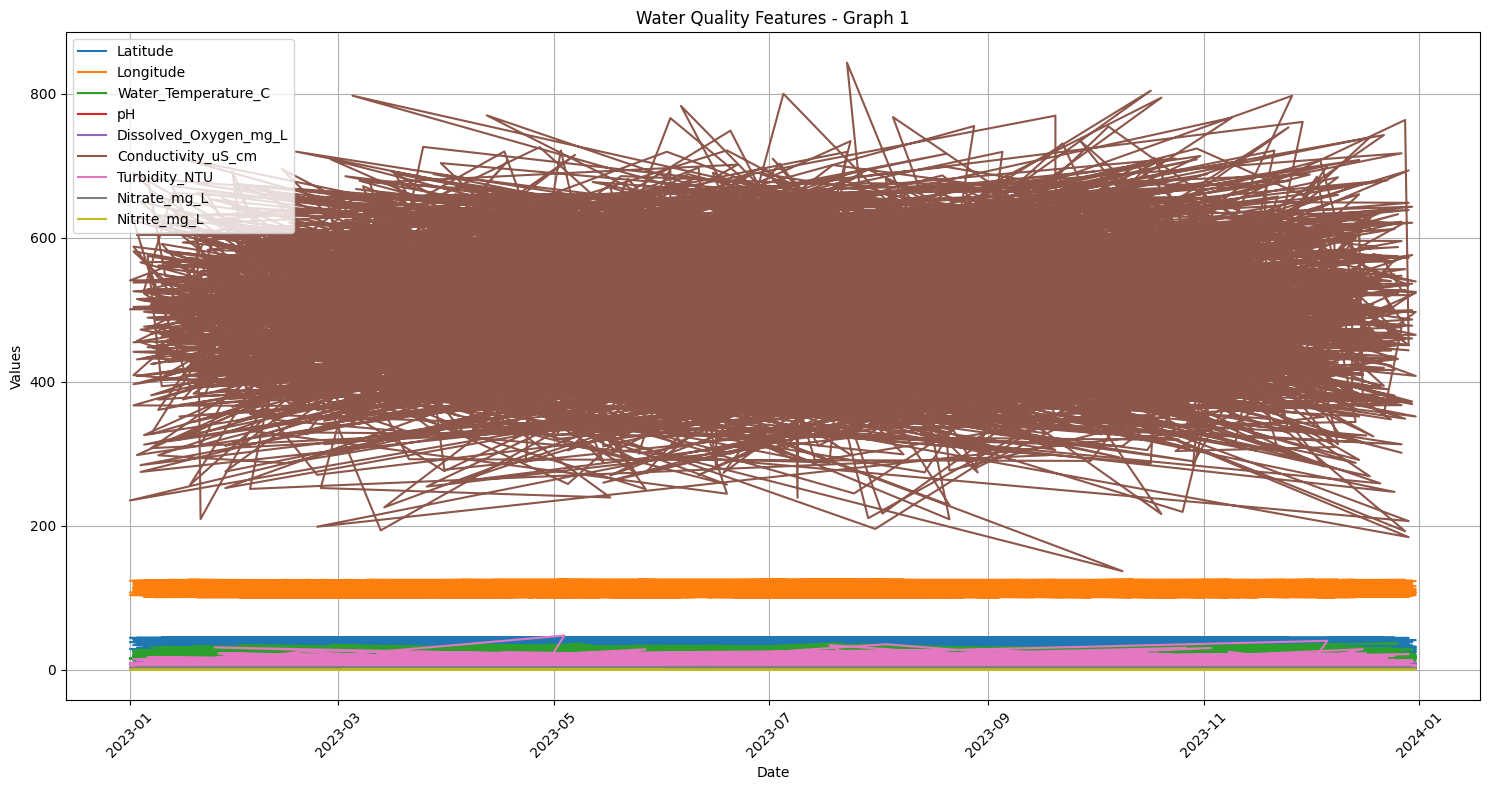

In [58]:

df['Date'] = pd.to_datetime(df['Date'])

numeric_columns = df.select_dtypes(include='number').columns

first_half = numeric_columns[:len(numeric_columns)//2]

plt.figure(figsize=(15, 8))

for column in first_half:
    plt.plot(df['Date'], df[column], label=column)

plt.title('Water Quality Features - Graph 1')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

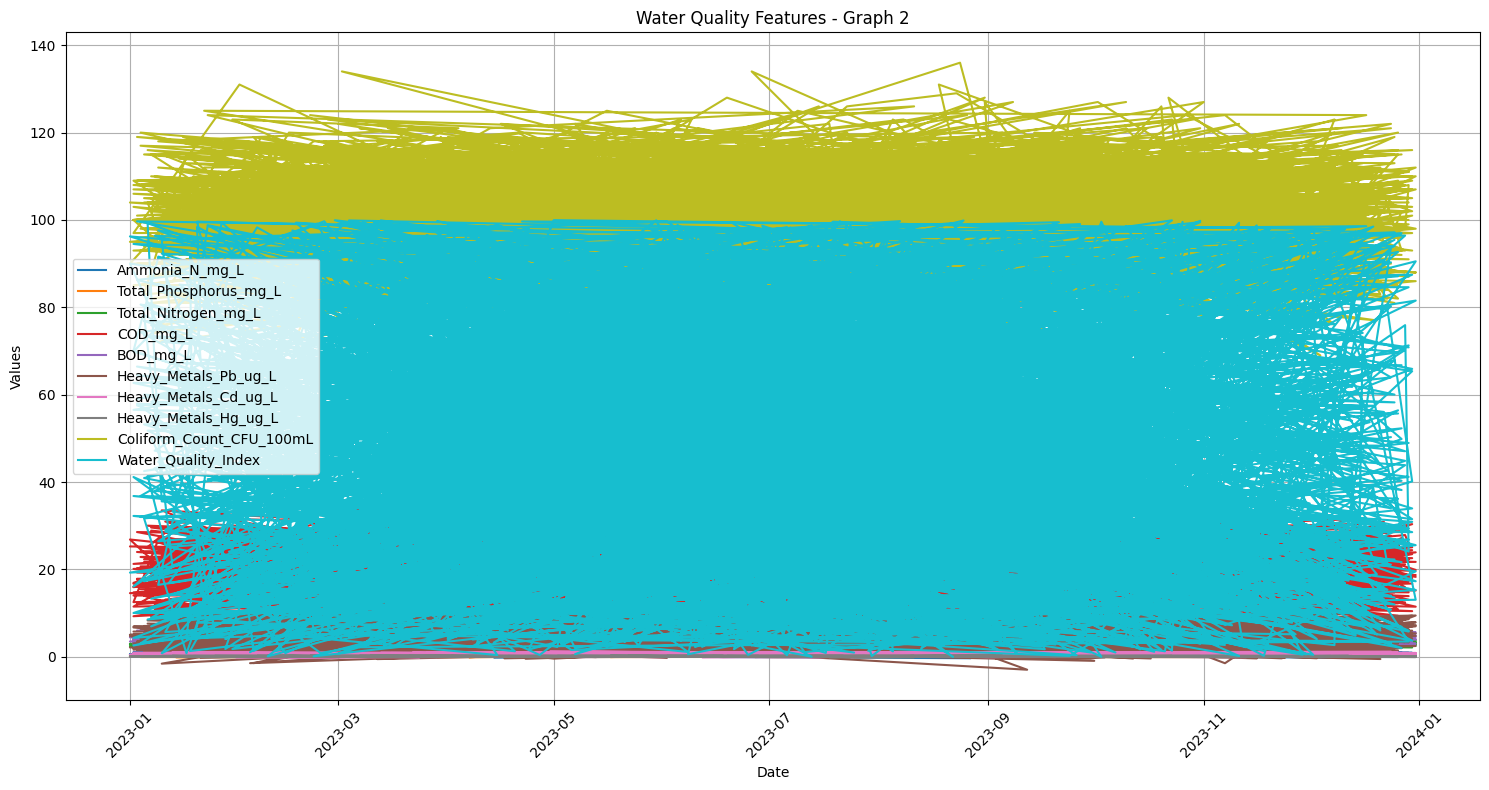

In [59]:
second_half = numeric_columns[len(numeric_columns)//2:]

plt.figure(figsize=(15, 8))

for column in second_half:
    plt.plot(df['Date'], df[column], label=column)

plt.title('Water Quality Features - Graph 2')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

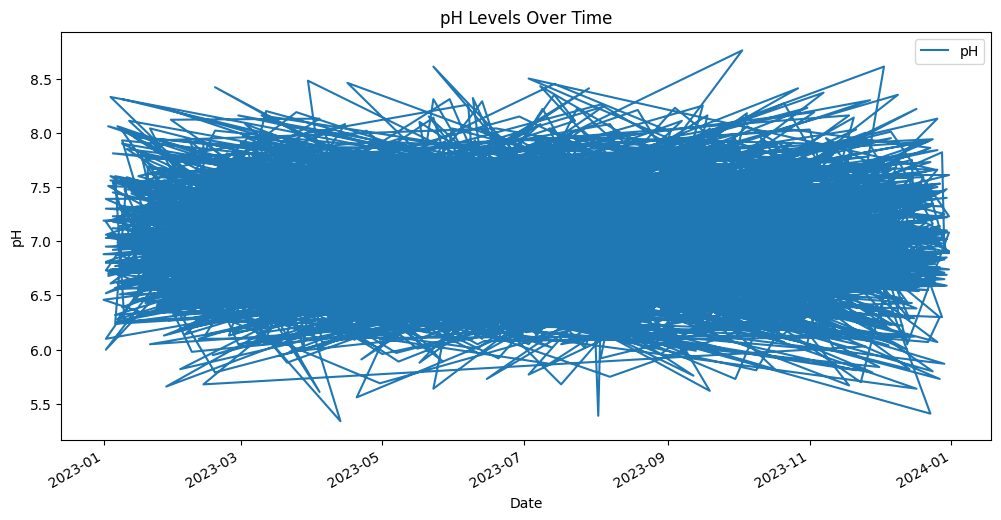

In [90]:

df.plot(
    x='Date',
    y='pH',
    kind='line',
    figsize=(12, 6)
)

plt.title('pH Levels Over Time')
plt.xlabel('Date')
plt.ylabel('pH')
plt.show()
print("\n")

Visualisations to understand patterns and relationships in the water-quality data.

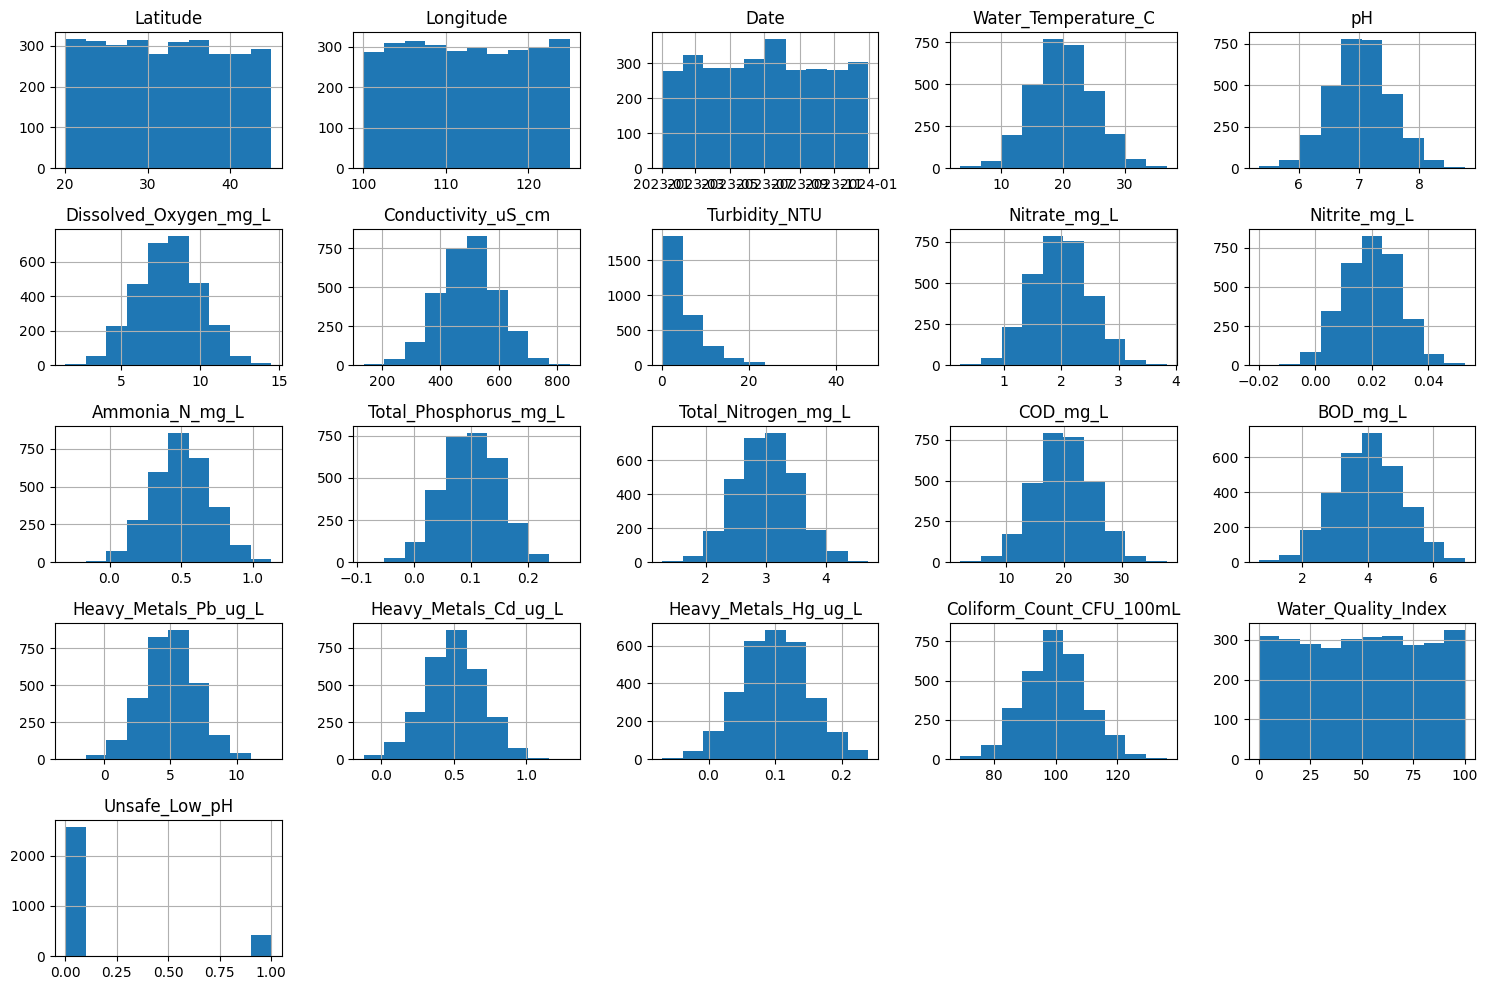

In [103]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

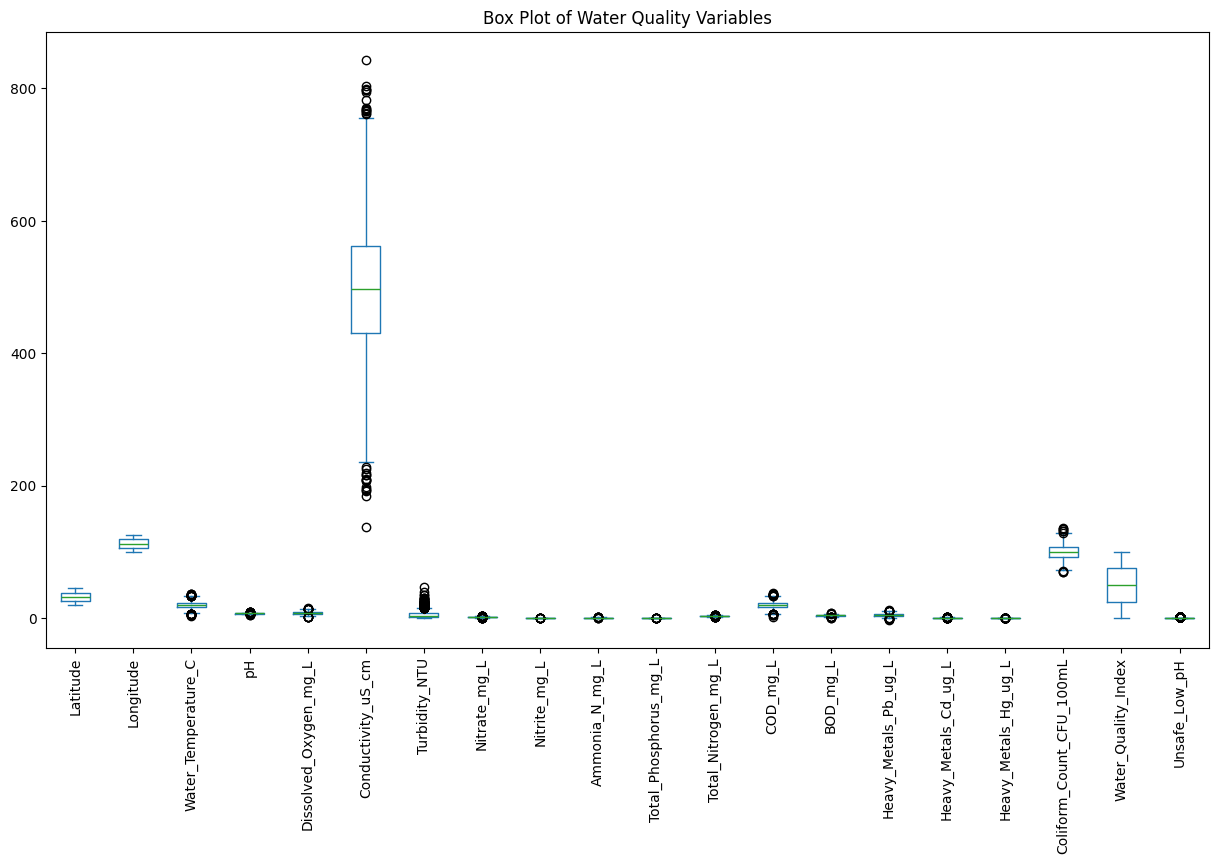

In [105]:
df.plot(
    kind='box',
    figsize=(15, 8),
    rot=90
)

plt.title("Box Plot of Water Quality Variables")
plt.show()

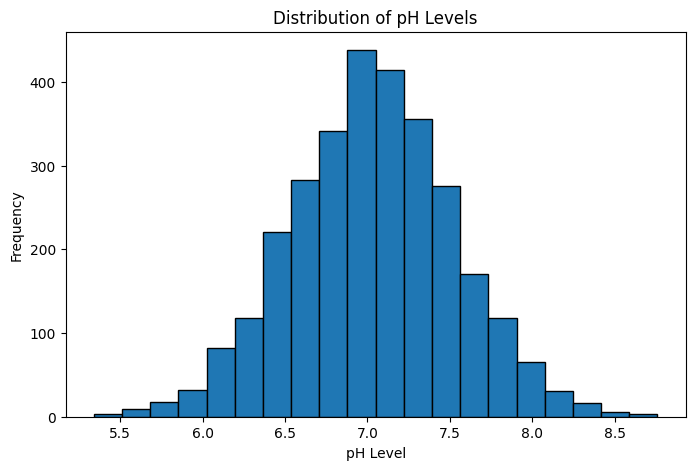

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['pH'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of pH Levels')
plt.xlabel('pH Level')
plt.ylabel('Frequency')
plt.show()

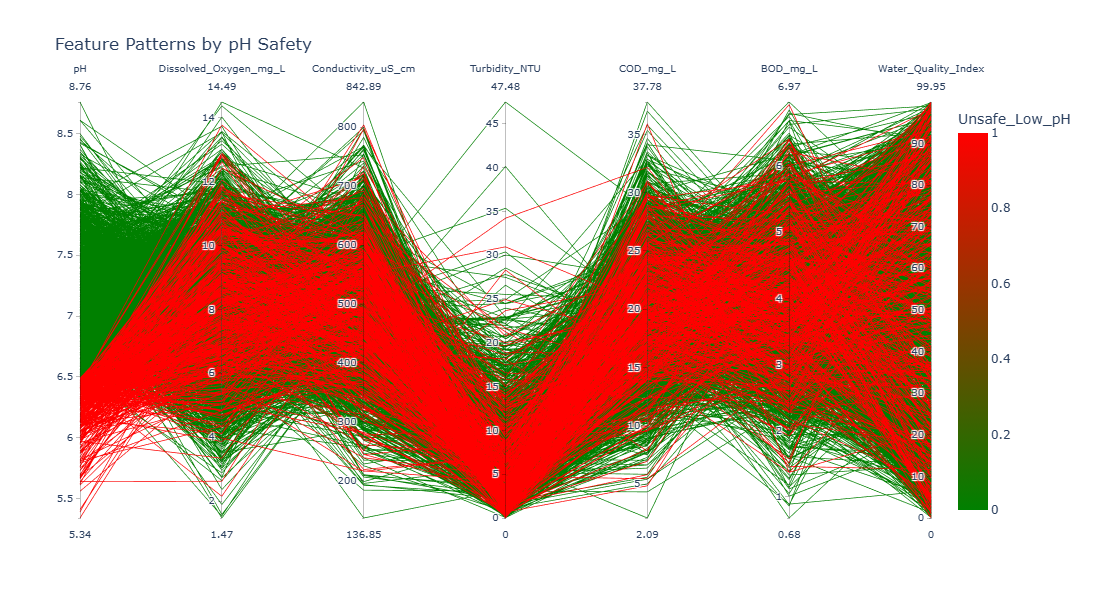

In [91]:
import plotly.express as px
fig = px.parallel_coordinates(
    df,
    dimensions=[
        'pH',
        'Dissolved_Oxygen_mg_L',
        'Conductivity_uS_cm',
        'Turbidity_NTU',
        'COD_mg_L',
        'BOD_mg_L',
        'Water_Quality_Index'
    ],
    color='Unsafe_Low_pH',
    color_continuous_scale=['green', 'red'],
    title='Feature Patterns by pH Safety'
)

fig.update_layout(height=600)

fig.show()

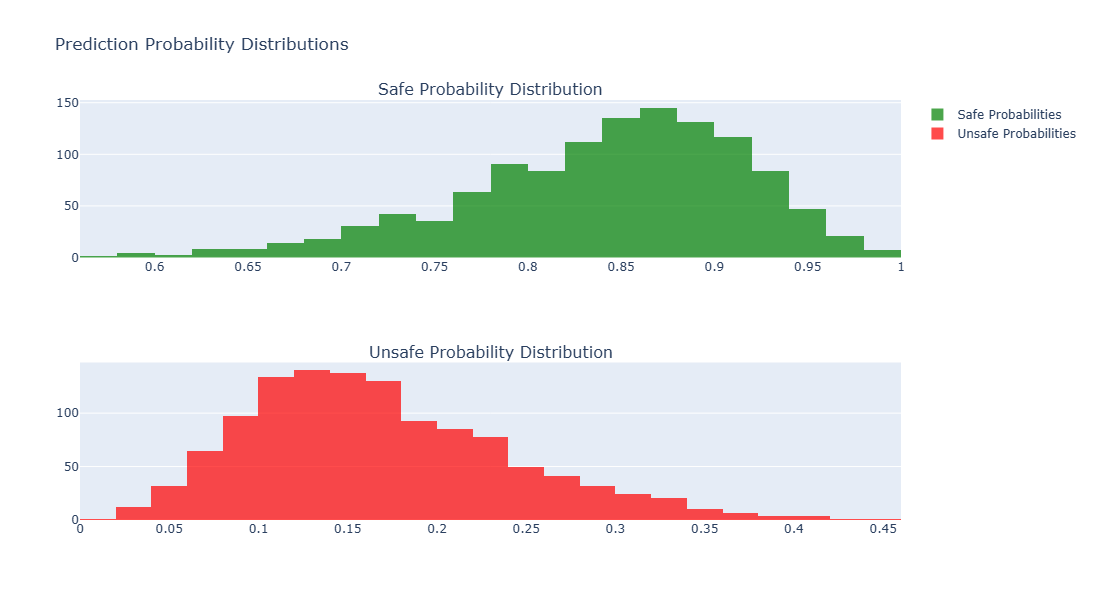

In [93]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Get prediction probabilities from the trained model
probabilities = model.predict_proba(X_test)

# Create a DataFrame containing the probabilities and predictions
prob_df = pd.DataFrame({
    'Safe_Probability': probabilities[:, 0],
    'Unsafe_Probability': probabilities[:, 1],
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Create two graphs
fig = make_subplots(
    rows=2,
    cols=1,
    subplot_titles=(
        'Safe Probability Distribution',
        'Unsafe Probability Distribution'
    )
)

# Safe probability
fig.add_trace(
    go.Histogram(
        x=prob_df['Safe_Probability'],
        nbinsx=30,
        name='Safe Probabilities',
        marker_color='green',
        opacity=0.7
    ),
    row=1,
    col=1
)

# Unsafe probability
fig.add_trace(
    go.Histogram(
        x=prob_df['Unsafe_Probability'],
        nbinsx=30,
        name='Unsafe Probabilities',
        marker_color='red',
        opacity=0.7
    ),
    row=2,
    col=1
)

fig.update_layout(
    height=600,
    title_text="Prediction Probability Distributions"
)

fig.show()

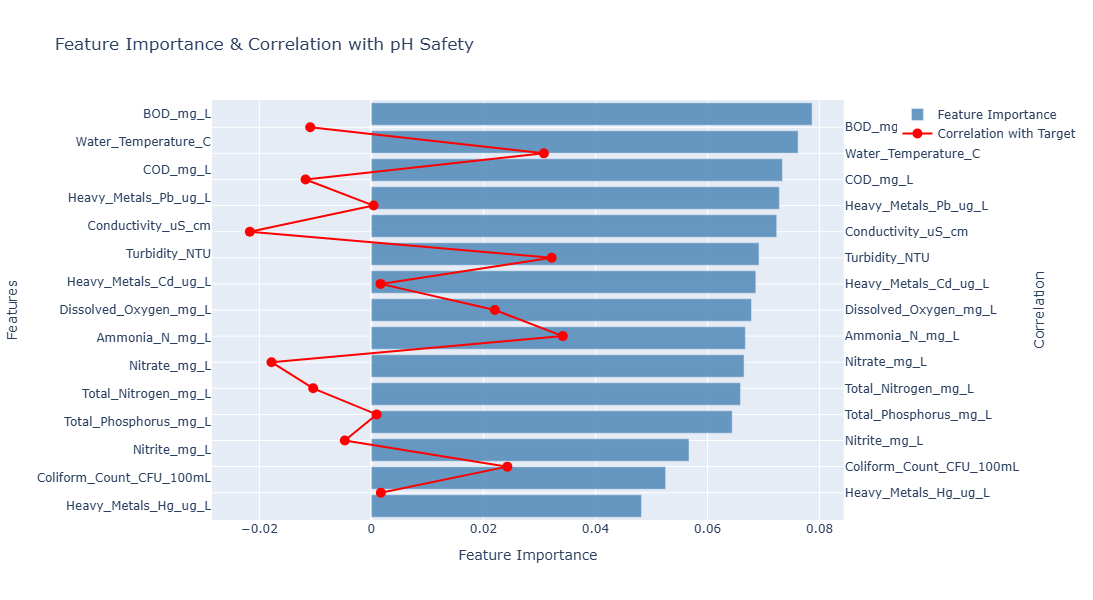

In [94]:
correlations = df[features].corrwith(
    df['Unsafe_Low_pH']
).sort_values(ascending=False)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_,
    'Correlation': [
        correlations[feat] for feat in features
    ]
}).sort_values('Importance', ascending=True)

fig = make_subplots(
    specs=[[{"secondary_y": True}]]
)

fig.add_trace(
    go.Bar(
        x=importance_df['Importance'],
        y=importance_df['Feature'],
        orientation='h',
        name='Feature Importance',
        marker_color='steelblue',
        opacity=0.8
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=importance_df['Correlation'],
        y=importance_df['Feature'],
        mode='markers+lines',
        name='Correlation with Target',
        marker=dict(size=10, color='red'),
        line=dict(color='red', width=2)
    ),
    secondary_y=True
)

fig.update_layout(
    title='Feature Importance & Correlation with pH Safety',
    height=600,
    xaxis_title='Feature Importance',
    yaxis_title='Features'
)

fig.update_yaxes(
    title_text='Correlation',
    secondary_y=True
)

fig.show()

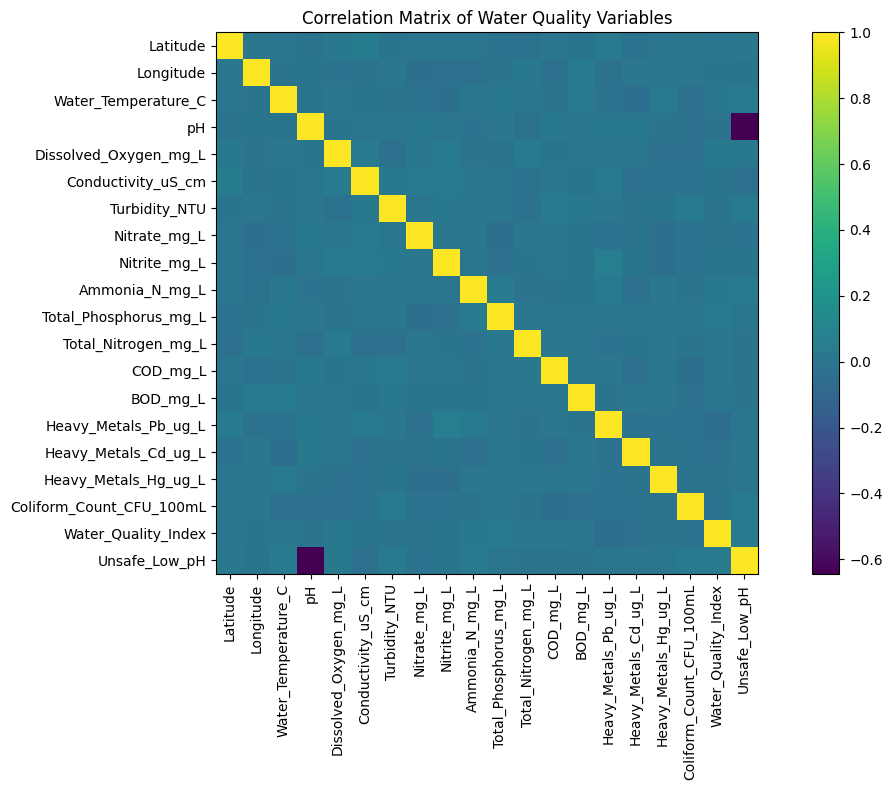

In [98]:
import matplotlib.pyplot as plt

correlation = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation)
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title('Correlation Matrix of Water Quality Variables')
plt.tight_layout()
plt.show()
plt.show()

In [101]:
correlation = df.select_dtypes(include='number').corr()

correlation

,Latitude,Longitude,Water_Temperature_C,pH,Dissolved_Oxygen_mg_L,Conductivity_uS_cm,Turbidity_NTU,Nitrate_mg_L,Nitrite_mg_L,Ammonia_N_mg_L,Total_Phosphorus_mg_L,Total_Nitrogen_mg_L,COD_mg_L,BOD_mg_L,Heavy_Metals_Pb_ug_L,Heavy_Metals_Cd_ug_L,Heavy_Metals_Hg_ug_L,Coliform_Count_CFU_100mL,Water_Quality_Index,Unsafe_Low_pH
Latitude,1.000000,0.008098,0.003138,-0.014318,0.017354,0.044282,-0.005330,-0.000030,-0.000829,0.000197,-0.018285,-0.025149,0.002321,-0.007571,0.025122,-0.016728,0.001570,0.009893,0.000199,0.015843
Longitude,0.008098,1.000000,-0.011626,-0.004627,-0.015465,-0.009865,0.001535,-0.038676,-0.031432,-0.033496,-0.009664,0.021338,-0.026870,0.034311,-0.022773,0.006531,0.005947,0.007649,-0.008407,-0.004913
Water_Temperature_C,0.003138,-0.011626,1.000000,-0.006433,0.004885,-0.008480,-0.012772,-0.020560,-0.037085,0.012923,0.018027,-0.000005,-0.013760,0.036570,-0.021017,-0.047077,0.029010,-0.025661,0.012051,0.030788
pH,-0.014318,-0.004627,-0.006433,1.000000,-0.003483,0.004164,0.002526,0.017634,-0.001934,-0.018342,0.004448,-0.026160,0.020986,0.001806,0.021984,0.017714,-0.010857,-0.030304,-0.013472,-0.644592
Dissolved_Oxygen_mg_L,0.017354,-0.015465,0.004885,-0.003483,1.000000,0.026660,-0.024186,0.015018,0.029960,-0.009456,-0.013702,0.035717,-0.002696,0.016559,0.014471,0.001617,-0.027234,-0.027732,0.018523,0.022046
Conductivity_uS_cm,0.044282,-0.009865,-0.008480,0.004164,0.026660,1.000000,0.021756,0.026211,0.023677,0.010238,0.002509,-0.021447,0.016518,-0.006869,0.026554,-0.029845,-0.020264,-0.019560,-0.003677,-0.021696
Turbidity_NTU,-0.005330,0.001535,-0.012772,0.002526,-0.024186,0.021756,1.000000,0.002241,0.023182,0.009736,0.001366,-0.026215,0.038459,0.018309,0.009147,-0.008991,-0.005798,0.041421,-0.014081,0.032178
Nitrate_mg_L,-0.000030,-0.038676,-0.020560,0.017634,0.015018,0.026211,0.002241,1.000000,0.014302,0.015600,-0.035224,0.004340,0.005151,-0.006118,-0.029599,-0.014830,-0.034426,-0.019101,-0.012055,-0.017834
Nitrite_mg_L,-0.000829,-0.031432,-0.037085,-0.001934,0.029960,0.023677,0.023182,0.014302,1.000000,0.003210,-0.022385,-0.007425,0.003065,-0.005032,0.061518,-0.007700,-0.040221,-0.016899,-0.003979,-0.004744
Ammonia_N_mg_L,0.000197,-0.033496,0.012923,-0.018342,-0.009456,0.010238,0.009736,0.015600,0.003210,1.000000,0.029890,-0.019641,-0.010952,-0.004986,0.024175,-0.021628,0.008828,-0.014772,0.022630,0.034169


## 4.Engineer Features

 Features importance

In [73]:
features = [
    "Water_Temperature_C",
    "Dissolved_Oxygen_mg_L",
    "Conductivity_uS_cm",
    "Turbidity_NTU",
    "Nitrate_mg_L",
    "Nitrite_mg_L",
    "Ammonia_N_mg_L",
    "Total_Phosphorus_mg_L",
    "Total_Nitrogen_mg_L",
    "COD_mg_L",
    "BOD_mg_L",
    "Heavy_Metals_Pb_ug_L",
    "Heavy_Metals_Cd_ug_L",
    "Heavy_Metals_Hg_ug_L",
    "Coliform_Count_CFU_100mL"
]

X = df[features]


y = df["pH"]


X = X.fillna(X.median())

print("Number of features:", len(features))
print("Features:")

for feature in features:
    print("-", feature)

print("\nTarget variable: pH\n")

Number of features: 15
Features:
- Water_Temperature_C
- Dissolved_Oxygen_mg_L
- Conductivity_uS_cm
- Turbidity_NTU
- Nitrate_mg_L
- Nitrite_mg_L
- Ammonia_N_mg_L
- Total_Phosphorus_mg_L
- Total_Nitrogen_mg_L
- COD_mg_L
- BOD_mg_L
- Heavy_Metals_Pb_ug_L
- Heavy_Metals_Cd_ug_L
- Heavy_Metals_Hg_ug_L
- Coliform_Count_CFU_100mL

Target variable: pH



Target variable creation

In [67]:
df["Unsafe_Low_pH"] = (df["pH"] < 6.5).astype(int)


print()
print("Safe (pH >= 6.5):", (df["Unsafe_Low_pH"] == 0).sum())
print("Unsafe (pH < 6.5):", (df["Unsafe_Low_pH"] == 1).sum())


Safe (pH >= 6.5): 2573
Unsafe (pH < 6.5): 427


Low pH Safety Classification

In [76]:

df["Unsafe_Low_pH"] = (df["pH"] < 6.5).astype(int)


safe_samples = (df["Unsafe_Low_pH"] == 0).sum()
unsafe_samples = (df["Unsafe_Low_pH"] == 1).sum()

print("Low pH Analysis\n")
print("Safe samples (pH >= 6.5):", safe_samples)
print("Unsafe samples (pH < 6.5):", unsafe_samples)


df["pH_Status"] = df["Unsafe_Low_pH"].map({
    0: "Safe",
    1: "Unsafe"
})

display(df[["pH", "pH_Status"]].head(10))

Low pH Analysis

Safe samples (pH >= 6.5): 2573
Unsafe samples (pH < 6.5): 427


,pH,pH_Status
0,6.93,Safe
1,6.89,Safe
2,6.02,Unsafe
3,7.31,Safe
4,7.77,Safe
5,7.16,Safe
6,7.20,Safe
7,7.38,Safe
8,7.77,Safe
9,7.17,Safe


Target variable for classification

In [81]:

y = df["Unsafe_Low_pH"]

print(y.value_counts(),"\n")


Unsafe_Low_pH
0    2573
1     427
Name: count, dtype: int64 



## 5.Train Model 

Split the dataset into 60 training and 40 testing

In [80]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training percentage:", round(len(X_train) / len(X) * 100, 2), "%")
print("Testing percentage:", round(len(X_test) / len(X) * 100, 2), "%")

Training samples: 1800
Testing samples: 1200
Training percentage: 60.0 %
Testing percentage: 40.0 %


Random Forest Classifier.

In [87]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully.\n")

Model training completed successfully.



Make predictions

In [201]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

_pred = rf_model.predict(X_test)

print("Predictions completed.")
print(y_pred[:10])

Predictions completed.
[0 0 0 0 0 0 0 0 0 0]


## 6.Test Model

Check how accurately your trained model predicts


In [192]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 1800
Validation samples: 600
Test samples: 600


In [195]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [197]:
y_test_pred = rf_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

Test Accuracy: 85.67 %


In [196]:
from sklearn.metrics import accuracy_score

y_val_pred = rf_model.predict(X_val)

validation_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print(
    "Validation Accuracy:",
    round(validation_accuracy * 100, 2),
    "%"
)

Validation Accuracy: 85.83 %


In [198]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Safe", "Unsafe"]
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_test_pred
    )
)

Classification Report:
              precision    recall  f1-score   support

        Safe       0.86      1.00      0.92       514
      Unsafe       0.00      0.00      0.00        86

    accuracy                           0.86       600
   macro avg       0.43      0.50      0.46       600
weighted avg       0.73      0.86      0.79       600


Confusion Matrix:
[[514   0]
 [ 86   0]]


C:\Users\Bambh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Bambh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Bambh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Text(0.5, 1.0, 'Random Forest Confusion Matrix')

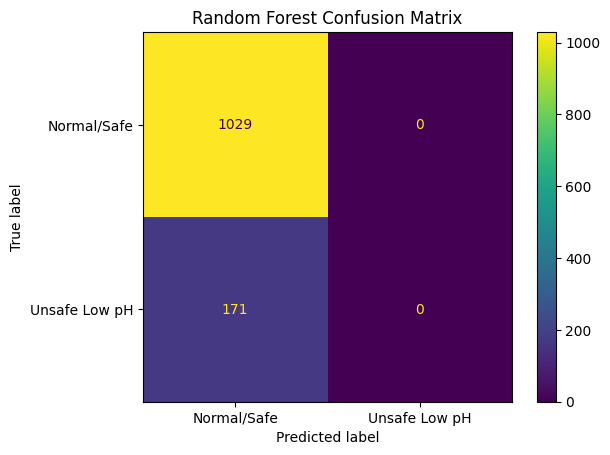

In [199]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal/Safe",
        "Unsafe Low pH"
    ]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")


Shows correct and incorrect classifications

In [110]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1029    0]
 [ 171    0]]


## 7 Evaluate Model.

Evaluate forecasts using MAE, MSE and RMSE

In [129]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


y_actual = y_test


y_forecast = model.predict(X_test)


mae = mean_absolute_error(y_actual, y_forecast)


mse = mean_squared_error(y_actual, y_forecast)


rmse = np.sqrt(mse)

print("Forecast Evaluation\n")
print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))

Forecast Evaluation

MAE: 0.1425
MSE: 0.1425
RMSE: 0.3775


K-Means clusters

In [155]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select water-quality features
features = [
    "pH",
    "Dissolved_Oxygen_mg_L",
    "Conductivity_uS_cm",
    "Turbidity_NTU",
    "COD_mg_L",
    "BOD_mg_L",
    "Water_Quality_Index"
]

# Handle missing values
X_cluster = df[features].fillna(df[features].median())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply K-Means with 5 clusters
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# Calculate average pH for each cluster
cluster_pH = df.groupby("Cluster")["pH"].mean().sort_values()

# Assign water-quality status to all 5 clusters
status_labels = {
    cluster_pH.index[0]: "Very Unsafe",
    cluster_pH.index[1]: "Unsafe",
    cluster_pH.index[2]: "Moderate",
    cluster_pH.index[3]: "Safe",
    cluster_pH.index[4]: "Very Safe"
}

df["KMeans_Status"] = df["Cluster"].map(status_labels)

# Display the first 10 results
display(
    df[[
        "pH",
        "Water_Quality_Index",
        "Cluster",
        "KMeans_Status"
    ]].head(10)
)

,pH,Water_Quality_Index,Cluster,KMeans_Status
0,6.93,36.64,0,Moderate
1,6.89,66.25,4,Safe
2,6.02,98.69,2,Unsafe
3,7.31,71.32,1,Very Unsafe
4,7.77,16.12,0,Moderate
5,7.16,33.76,2,Unsafe
6,7.20,48.95,1,Very Unsafe
7,7.38,17.44,3,Very Safe
8,7.77,89.71,2,Unsafe
9,7.17,84.92,4,Safe


In [168]:
cluster_summary = df.groupby("Cluster")["pH"].mean()

print("Average pH for each cluster:")
print(cluster_summary)
print("\n")

Average pH for each cluster:
Cluster
0    7.052096
1    6.901265
2    7.033686
3    7.093215
4    7.074093
Name: pH, dtype: float64




Time Series Forecasting using Prophet

In [169]:
import pandas as pd


df["Date"] = pd.to_datetime(df["Date"])


ts_data = df[["Date", "pH"]].copy()


ts_data = ts_data.rename(columns={
    "Date": "ds",
    "pH": "y"
})


ts_data = ts_data.sort_values("ds")


ts_data = ts_data.dropna()

display(ts_data.head())


,ds,y
739,2023-01-01,6.46
2141,2023-01-01,6.88
2587,2023-01-01,7.19
2699,2023-01-02,6.95
2139,2023-01-02,7.03


Install and import Prophet

In [171]:
!pip install prophet


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [172]:
from prophet import Prophet

C:\Users\Bambh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train the Prophet model

In [173]:
model = Prophet()

model.fit(ts_data)

print("Prophet model trained successfully.")

04:12:18 - cmdstanpy - INFO - Chain [1] start processing
04:12:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


Future dates


In [174]:
future = model.make_future_dataframe(
    periods=30,
    freq="D"
)

display(future.tail())

,ds
390,2024-01-26
391,2024-01-27
392,2024-01-28
393,2024-01-29
394,2024-01-30


Make the forecast

In [175]:
forecast = model.predict(future)

display(
    forecast[[
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]].tail(30)
)

,ds,yhat,yhat_lower,yhat_upper
365,2024-01-01,7.000498,6.375624,7.568552
366,2024-01-02,6.989993,6.289309,7.628631
367,2024-01-03,6.978183,6.335018,7.650955
368,2024-01-04,6.997414,6.390799,7.636361
369,2024-01-05,7.034818,6.386090,7.660979
370,2024-01-06,7.041886,6.439198,7.691231
371,2024-01-07,6.996153,6.374527,7.689124
372,2024-01-08,6.997884,6.364391,7.640572
373,2024-01-09,6.987379,6.396516,7.640503
374,2024-01-10,6.975570,6.371977,7.585686


Plot the forecast

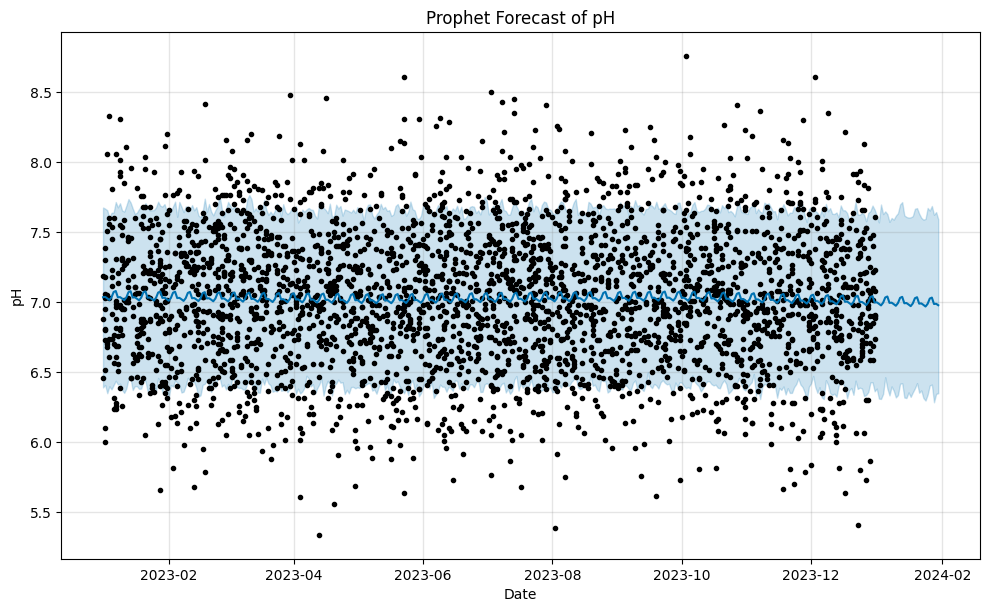

In [177]:
import matplotlib.pyplot as plt

fig = model.plot(forecast)

plt.title("Prophet Forecast of pH")
plt.xlabel("Date")
plt.ylabel("pH")
plt.show()

Show the trend for years and days

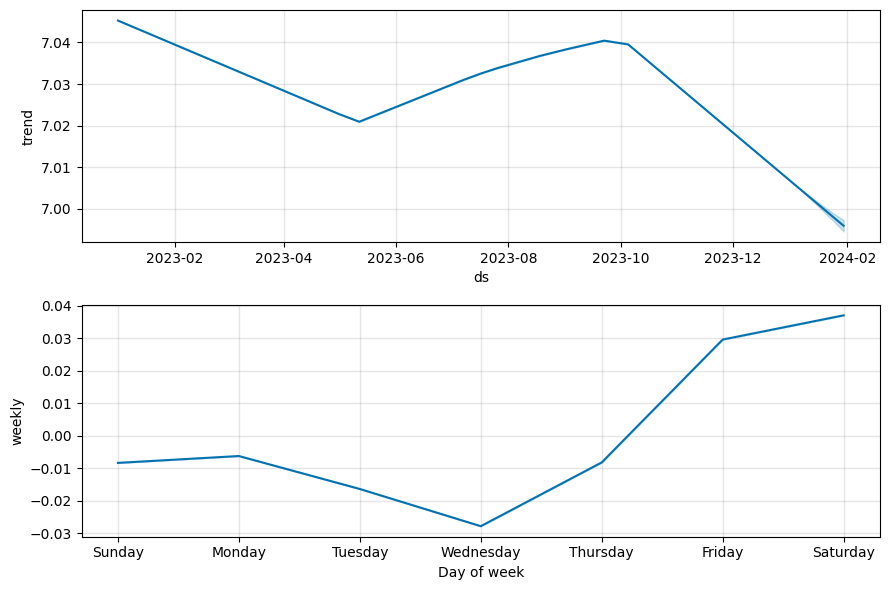

In [178]:
fig = model.plot_components(forecast)

plt.show()

Calculate forecast errors

In [179]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

split_index = int(len(ts_data) * 0.80)

train_data = ts_data.iloc[:split_index]
test_data = ts_data.iloc[split_index:]

model = Prophet()
model.fit(train_data)


future_test = model.predict(test_data[["ds"]])


actual = test_data["y"].values
predicted = future_test["yhat"].values


mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)

print("Time Series Forecast Evaluation")
print("--------------------------------")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))

04:13:40 - cmdstanpy - INFO - Chain [1] start processing
04:13:40 - cmdstanpy - INFO - Chain [1] done processing


Time Series Forecast Evaluation
--------------------------------
MAE: 0.397
MSE: 0.256
RMSE: 0.506


## 8.Deploy Model

In [204]:
from sklearn.ensemble import RandomForestClassifier

# Create the final model
final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train using the available dataset
final_model.fit(X, y)

print("Final model trained successfully.")

Final model trained successfully.


Test it with new water-quality data

In [203]:
new_data = [[
    25.5,    # Water_Temperature_C
    7.2,     # Dissolved_Oxygen_mg_L
    450,     # Conductivity_uS_cm
    3.5,     # Turbidity_NTU
    2.1,     # Nitrate_mg_L
    0.05,    # Nitrite_mg_L
    0.2,     # Ammonia_N_mg_L
    0.08,    # Total_Phosphorus_mg_L
    1.5,     # Total_Nitrogen_mg_L
    25,      # COD_mg_L
    4,       # BOD_mg_L
    10,      # Heavy_Metals_Pb_ug_L
    2,       # Heavy_Metals_Cd_ug_L
    0.01,    # Heavy_Metals_Hg_ug_L
    500      # Coliform_Count_CFU_100mL
]]

prediction =final_model.predict(new_data)

if prediction[0] == 1:
    print("Prediction: Unsafe")
else:
    print("Prediction: Safe")

Prediction: Unsafe


C:\Users\Bambh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Show prediction probabilities

In [205]:
probability = final_model.predict_proba(new_data)

print("Safe Probability:", round(probability[0][0] * 100, 2), "%")
print("Unsafe Probability:", round(probability[0][1] * 100, 2), "%")

Safe Probability: 49.0 %
Unsafe Probability: 51.0 %


C:\Users\Bambh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Conclusion

This project used data science and machine learning to analyse water pollution and predict unsafe low-pH water. The pH values were used to create the `Unsafe_Low_pH` target, where water with a pH below 6.5 is classified as unsafe and water with a pH of 6.5 or above is classified as normal/safe.

The dataset was cleaned by removing duplicate records and handling missing values. Relevant water-quality measurements such as dissolved oxygen, conductivity, turbidity, nitrate, nitrite, ammonia, nutrients, COD, BOD, heavy metals, and coliform count were used as input features. The original pH variable was removed from the model inputs to prevent data leakage.

A Random Forest classification model was trained using 60% of the data and evaluated using the remaining 40% unseen test data. The test accuracy, classification report, and confusion matrix were used to evaluate how well the model identifies normal/safe and unsafe low-pH water. Feature importance was also analysed to identify which water-quality measurements contributed most to the model's predictions.

Overall, the project demonstrates how machine learning can be used as a tool to support water-quality monitoring and identify potentially unsafe acidic water. The model's performance should be interpreted using the test results produced in this notebook, and further improvement could be achieved by using more data, additional relevant features, and model tuning.
